<a href="https://colab.research.google.com/github/miku390219/ml-practice/blob/main/Data6_modelPractice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Insurance Cost Analysis

# Summary<データ処理の流れ>


1.   データのインポート

1.   データ前処理
2.   EDA


2.   モデル開発

1.   モデルの改良







#Import the Dataset


In [ ]:
# ライブラリのインストール（Colabには多くが既にインストール済みだが念のため）
!pip install pandas matplotlib scipy scikit-learn seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ファイルのダウンロード
import urllib.request

url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/medical_insurance_dataset.csv'
file_name = "insurance.csv"

urllib.request.urlretrieve(url, file_name)

df = pd.read_csv(file_name, header = None)

In [ ]:
df.head()

,0,1,2,3,4,5,6
0,19,1,27.900,0,1,3,16884.92400
1,18,2,33.770,1,0,4,1725.55230
2,28,2,33.000,3,0,4,4449.46200
3,33,2,22.705,0,0,1,21984.47061
4,32,2,28.880,0,0,1,3866.85520


In [ ]:
df.head(10)

,0,1,2,3,4,5,6
0,19,1,27.900,0,1,3,16884.92400
1,18,2,33.770,1,0,4,1725.55230
2,28,2,33.000,3,0,4,4449.46200
3,33,2,22.705,0,0,1,21984.47061
4,32,2,28.880,0,0,1,3866.85520
5,31,1,25.740,0,?,4,3756.62160
6,46,1,33.440,1,0,4,8240.58960
7,37,1,27.740,3,0,1,7281.50560
8,37,2,29.830,2,0,2,6406.41070
9,60,1,25.840,0,0,1,28923.13692


In [ ]:
headers = ["age", "gender", "bmi", "no_of_children", "smoker", "region", "charges"]

In [ ]:
df.columns = headers

In [ ]:
df.replace("?", np.nan, inplace = True)
df.head(10)

,age,gender,bmi,no_of_children,smoker,region,charges
0,19,1,27.900,0,1,3,16884.92400
1,18,2,33.770,1,0,4,1725.55230
2,28,2,33.000,3,0,4,4449.46200
3,33,2,22.705,0,0,1,21984.47061
4,32,2,28.880,0,0,1,3866.85520
5,31,1,25.740,0,NaN,4,3756.62160
6,46,1,33.440,1,0,4,8240.58960
7,37,1,27.740,3,0,1,7281.50560
8,37,2,29.830,2,0,2,6406.41070
9,60,1,25.840,0,0,1,28923.13692


# Data Wrangling


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2768 non-null   object 
 1   gender          2772 non-null   int64  
 2   bmi             2772 non-null   float64
 3   no_of_children  2772 non-null   int64  
 4   smoker          2765 non-null   object 
 5   region          2772 non-null   int64  
 6   charges         2772 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 151.7+ KB


In [ ]:
#Handle missing data
#PangeIndex:2772・・・データ数は2772個。Non-null < 2772の列のみNanを補完
# -->age, smokerを補完

In [ ]:
ageAve = df['age'].astype(float).mean(axis=0)
print(ageAve)
df['age'].replace(np.nan, ageAve, inplace = True)

39.10982658959538


In [ ]:
smokerMode = df['smoker'].value_counts().idxmax()
print(smokerMode)
df['smoker'].replace(np.nan, smokerMode, inplace=True)

0


In [ ]:
df.head(10)

,age,gender,bmi,no_of_children,smoker,region,charges
0,19,1,27.900,0,1,3,16884.92400
1,18,2,33.770,1,0,4,1725.55230
2,28,2,33.000,3,0,4,4449.46200
3,33,2,22.705,0,0,1,21984.47061
4,32,2,28.880,0,0,1,3866.85520
5,31,1,25.740,0,0,4,3756.62160
6,46,1,33.440,1,0,4,8240.58960
7,37,1,27.740,3,0,1,7281.50560
8,37,2,29.830,2,0,2,6406.41070
9,60,1,25.840,0,0,1,28923.13692


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2772 non-null   object 
 1   gender          2772 non-null   int64  
 2   bmi             2772 non-null   float64
 3   no_of_children  2772 non-null   int64  
 4   smoker          2772 non-null   object 
 5   region          2772 non-null   int64  
 6   charges         2772 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 151.7+ KB


In [ ]:
df[["charges"]] = np.round(df[["charges"]], 2)
print(df.head())

  age  gender     bmi  no_of_children smoker  region   charges
0  19       1  27.900               0      1       3  16884.92
1  18       2  33.770               1      0       4   1725.55
2  28       2  33.000               3      0       4   4449.46
3  33       2  22.705               0      0       1  21984.47
4  32       2  28.880               0      0       1   3866.86


# EDA

<Axes: xlabel='bmi', ylabel='charges'>

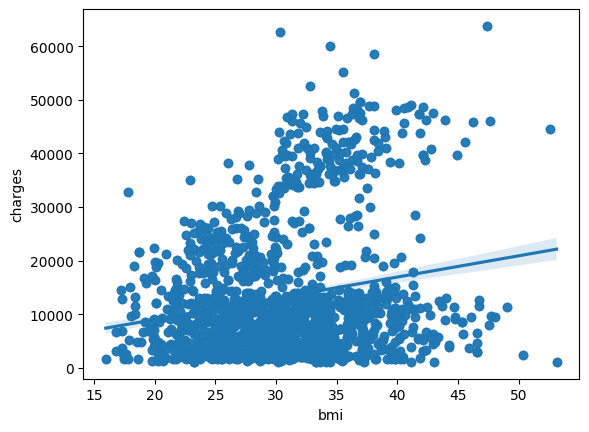

In [ ]:
import seaborn as sns
sns.regplot(x = "bmi", y = "charges", data=df)

<Axes: xlabel='smoker', ylabel='charges'>

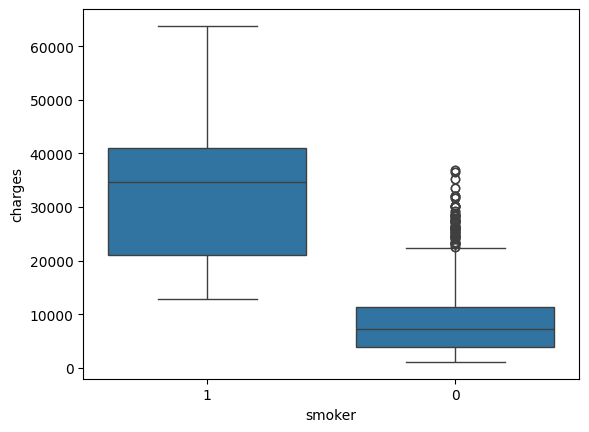

In [ ]:
sns.boxplot(x='smoker', y='charges', data=df)

In [ ]:
df.corr()

,age,gender,bmi,no_of_children,smoker,region,charges
age,1.000000,-0.026041,0.113045,0.037585,-0.023285,-0.007175,0.298622
gender,-0.026041,1.000000,0.042924,0.016020,0.082326,0.022213,0.062837
bmi,0.113045,0.042924,1.000000,-0.001492,0.011489,0.271119,0.199846
no_of_children,0.037585,0.016020,-0.001492,1.000000,0.006362,-0.025717,0.066442
smoker,-0.023285,0.082326,0.011489,0.006362,1.000000,0.054077,0.788783
region,-0.007175,0.022213,0.271119,-0.025717,0.054077,1.000000,0.054058
charges,0.298622,0.062837,0.199846,0.066442,0.788783,0.054058,1.000000


# Model Development

In [ ]:
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
X = df[['smoker']]
Y = df['charges']
lm.fit(X, Y)

LinearRegression()

In [ ]:
print(lm.score(X, Y))

0.6221791733924185


In [ ]:
Z = df[['age', 'gender', 'bmi','no_of_children', 'smoker', 'region']]
lm.fit(Z, Y)
print(lm.score(Z, Y))

0.7504063772187107


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
Input = [('scale', StandardScaler()), ('polynomial', PolynomialFeatures(include_bias=False)), ('model', LinearRegression())]
pipe = Pipeline(Input)
Z = Z.astype(float)
pipe.fit(Z, Y)
ypipe = pipe.predict(Z)
pipe.score(Z, Y)

0.8452558518297514

# Model Refinement

In [ ]:
from sklearn.model_selection import train_test_split
y_data = df['charges']
x_data=df.drop('charges',axis=1)
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.20, random_state=1)

In [ ]:
from sklearn.linear_model import Ridge
pr=PolynomialFeatures(degree=2)
RigeModel=Ridge(alpha=1)
RigeModel.fit(x_train, y_train)
yhat = RigeModel.predict(x_test)
print(RigeModel.score(x_test, y_test))

0.6762731556317978
